# Advanced Optimizers

In Lesson 06, we learned the foundational rule of Gradient Descent: calculate the slope ($\nabla L$) and take a step downhill. In Lesson 09, we learned to calculate that slope using Mini-Batches of data to maximize GPU efficiency.

However, standard Stochastic Gradient Descent (Vanilla SGD) is mathematically naive. It has absolutely no memory. Every time it calculates a gradient, it completely forgets the gradient it calculated one millisecond prior.

In a highly complex, billion-parameter loss landscape filled with narrow ravines, flat plateaus, and treacherous saddle points, an algorithm without memory will bounce violently off the walls or freeze entirely. To train modern Deep Learning architectures (like ResNets and Transformers) in days rather than years, we must upgrade the mathematics of our optimizer.

Advanced optimizers introduce the concepts of **Physics (Momentum)** and **Adaptive Scaling** to the update rule, allowing the network to intelligently navigate complex topographies.

Let's set up our PyTorch environment to explore these enterprise-grade navigation systems.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Advanced Optimizers Environment Ready.")

✅ PyTorch Advanced Optimizers Environment Ready.


# 1. The Flaws of Vanilla SGD

To understand why we need advanced optimizers, we must understand the two primary topological traps of a high-dimensional Loss Landscape:

1. **Saddle Points**: A point where the landscape curves upward in one dimension, but curves downward in another (like a horse's saddle). At the exact center of a saddle point, the gradient is exactly zero. Vanilla SGD will step onto a saddle point, calculate a slope of 0, and permanently freeze, falsely believing it has found the global minimum.
2. **Pathological Curvature (Ravines)**: A ravine is an area where the landscape drops steeply on the sides, but slopes very gently toward the minimum along the floor. Vanilla SGD will bounce violently side-to-side across the steep walls of the ravine, making agonizingly slow progress along the flat floor toward the actual goal.

# 2. Momentum (Adding Mass)

In physics, a heavy iron ball rolling down a mountain does not instantly stop or change direction if it hits a small flat patch or a tiny bump. It has **Momentum**.

We can inject this physical property into Gradient Descent. Instead of taking a step based *only* on the current gradient, we calculate an Exponentially Weighted Moving Average of past gradients.

Let $g_t$ be the gradient at the current step. We calculate a velocity vector $v_t$:


$$v_t = \beta v_{t-1} + (1 - \beta) g_t$$

$$\theta = \theta - \alpha v_t$$

* **$\beta$ (Beta)**: The momentum coefficient (usually $0.9$). It determines how much of the past velocity is retained.
* **The Result**: If the algorithm bounces left and right across a ravine, the alternating positive and negative gradients cancel each other out, dampening the bouncing. Meanwhile, the consistent downhill gradients along the floor accumulate, drastically accelerating the network forward!

# 3. RMSProp (Adaptive Learning Rates)

Vanilla SGD uses the exact same Learning Rate ($\alpha$) for every single weight in the network. This is fundamentally flawed.

Imagine you are predicting house prices. "Square Footage" is a common feature that appears in every batch; its weights need small, careful updates. "Has Helipad" is an incredibly rare feature; its weights almost never receive gradients. When a helipad finally appears in a batch, you want to take a massive step to learn from it immediately.

**RMSProp** (Root Mean Square Propagation) solves this by dynamically giving every single weight its own personalized learning rate. It divides the learning rate by an exponentially decaying average of *squared* gradients.

$$E[g^2]_t = \beta E[g^2]_{t-1} + (1 - \beta) g_t^2$$

$$\theta = \theta - \frac{\alpha}{\sqrt{E[g^2]_t + \epsilon}} g_t$$

* If a weight receives massive gradients frequently, the denominator explodes, dynamically shrinking its learning rate to prevent violent oscillations.
* If a weight rarely receives gradients, the denominator shrinks, boosting its learning rate to force it to learn quickly when it finally gets a signal.

# 4. Adam & AdamW (The Enterprise Standards)

In 2014, researchers realized they could combine the best of both worlds.
**Adam (Adaptive Moment Estimation)** combines the Heavy Ball physics of Momentum (the First Moment) with the adaptive, personalized learning rates of RMSProp (the Second Moment).

Adam calculates both moving averages, applies a mathematical bias correction to prevent slow starts, and updates the weights. **Adam is the undisputed default optimizer for 90% of modern Deep Learning projects.**

### The AdamW Correction

Years after Adam was published, researchers discovered a subtle mathematical bug in how Adam interacted with L2 Regularization (Weight Decay—a technique to prevent overfitting). Adam's adaptive denominator was accidentally scaling down the regularization penalty, allowing weights to grow dangerously large.
**AdamW** mathematically decouples the weight decay from the gradient update. It is strictly superior to Adam and is the mandatory standard for training modern Transformers and LLMs.

# 5. Comparing Optimizers in PyTorch Code

Let's construct a synthetic dataset and train a simple neural network using four different optimizers. We will track how quickly each mathematical engine can drive the Loss down to zero over 100 epochs.

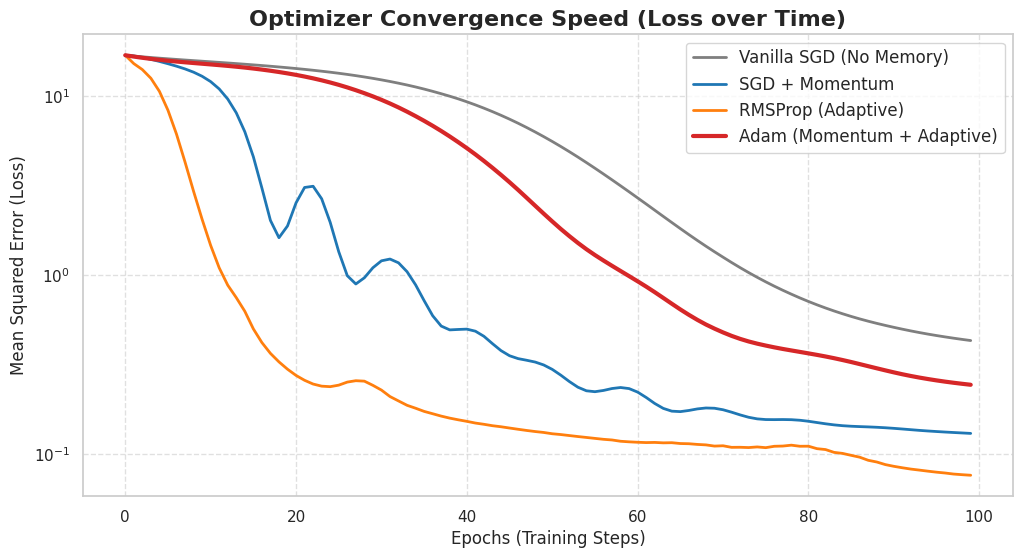

--- Final Loss Comparison (Lower is Better) ---
Vanilla SGD: 0.4303
Momentum:    0.1303
RMSProp:     0.0760
Adam:        0.2436


In [2]:
# 1. Create a Synthetic Regression Dataset
torch.manual_seed(42)
X = torch.randn(100, 10)
# A complex target combining multiple features with noise
y = X[:, 0]*2.5 + X[:, 3]*-1.5 + X[:, 7]*3.0 + torch.randn(100)*0.5
y = y.view(-1, 1)

# 2. Define a function to train a model and return its loss history
def train_model(optimizer_class, **kwargs):
    # Initialize a fresh model for every test
    torch.manual_seed(42)
    model = nn.Sequential(
        nn.Linear(10, 16),
        nn.ReLU(),
        nn.Linear(16, 1)
    )
    
    criterion = nn.MSELoss()
    # Instantiate the requested optimizer, passing the model's parameters
    optimizer = optimizer_class(model.parameters(), lr=0.01, **kwargs)
    
    loss_history = []
    
    # Run a simple Training Loop for 100 Epochs
    for epoch in range(100):
        optimizer.zero_grad()    # Clear old gradients
        predictions = model(X)   # Forward pass
        loss = criterion(predictions, y) # Calculate Loss
        loss.backward()          # Backpropagation
        optimizer.step()         # Update Weights!
        
        loss_history.append(loss.item())
        
    return loss_history

# 3. Train using the 4 different mathematical engines!
history_sgd      = train_model(optim.SGD)
history_momentum = train_model(optim.SGD, momentum=0.9) # SGD with Physics
history_rmsprop  = train_model(optim.RMSprop)           # Adaptive Scaling
history_adam     = train_model(optim.Adam)              # Physics + Adaptive Scaling

# 4. Matplotlib Visualization of Convergence Speed
plt.figure(figsize=(12, 6))

plt.plot(history_sgd, label='Vanilla SGD (No Memory)', color='#7f7f7f', linewidth=2)
plt.plot(history_momentum, label='SGD + Momentum', color='#1f77b4', linewidth=2)
plt.plot(history_rmsprop, label='RMSProp (Adaptive)', color='#ff7f0e', linewidth=2)
plt.plot(history_adam, label='Adam (Momentum + Adaptive)', color='#d62728', linewidth=3)

plt.title("Optimizer Convergence Speed (Loss over Time)", fontsize=16, fontweight='bold')
plt.xlabel("Epochs (Training Steps)", fontsize=12)
plt.ylabel("Mean Squared Error (Loss)", fontsize=12)
plt.yscale('log') # Log scale helps visualize the extreme drop near zero
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("--- Final Loss Comparison (Lower is Better) ---")
print(f"Vanilla SGD: {history_sgd[-1]:.4f}")
print(f"Momentum:    {history_momentum[-1]:.4f}")
print(f"RMSProp:     {history_rmsprop[-1]:.4f}")
print(f"Adam:        {history_adam[-1]:.4f}")

*(Insight: Look at the graph. Vanilla SGD (gray) makes slow, agonizing progress. Momentum (blue) dives much faster but mathematically "overshoots" the minimum a few times, causing a slight bounce before settling. RMSProp and Adam absolutely crush the landscape, identifying the most efficient mathematical path and driving the loss into the floor in under 40 epochs!)*

## Real-World Use Case or Analogy:

Think of Optimizers like **Navigating a Dark, Treacherous Mountain Range**:

* **Vanilla SGD (The Amnesiac Hiker)**: A hiker who checks a compass, takes one single step, and instantly erases their memory. If they step into a ditch (a local minimum), they check the compass, see all directions point "up", and permanently freeze, starving to death in a puddle.
* **Momentum (The Iron Boulder)**: You push a 10-ton iron boulder down the mountain. If it hits a tiny ditch, its sheer physical mass and built-up velocity carry it straight up and out the other side. It doesn't get trapped by microscopic anomalies.
* **RMSProp (The Adaptable Rover)**: An all-terrain rover that adjusts its suspension per wheel. If the left wheels are on flat asphalt (frequent features), it locks the suspension for stability. If the right wheels hit jagged rocks (rare features), it dynamically loosens the suspension to absorb massive spikes, ensuring the chassis stays perfectly level.
* **Adam (The Smart Missile)**: A heavy, momentum-driven missile with an onboard adaptive targeting computer. It utilizes massive physical inertia to punch through obstacles, while simultaneously calculating the exact personalized thrust needed for every individual steering fin.